In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import numpy as np
import yaml
import matplotlib as mpl

with open("../plotting_config.yaml", "r") as fp:
    config = yaml.safe_load(fp)

mpl.rcParams["svg.hashsalt"] = "42"



def is_accessable(x):
    result = 0
    if x > 0:
        result = 1
    return result


def generate_access_variables(data: pd.DataFrame) -> pd.DataFrame:
    copy = data.copy()
    for t in ["_multimodal", "_walk15"]:
        for e in essential:
            copy[e+t+"_d"] = copy[e+t].apply(is_accessable)

    copy["multimodal_sum"] = copy[[f"{i}_multimodal_d" for i in essential]].sum(axis=1)
    copy["walk_sum"] = copy[[f"{i}_walk15_d" for i in essential]].sum(axis=1)

    copy["multimodal_all"] = copy[[f"{i}_multimodal" for i in essential]].sum(axis=1)
    copy["walk_all"] = copy[[f"{i}_walk15" for i in essential]].sum(axis=1)

    return copy

In [3]:
essential = ["cultural_institutions", "drugstores", "groceries", "healthcare", "parks", "religious_organizations", "restaurants", "schools", "services"]

In [ ]:
bud = pd.read_csv("../output/budapest/20250428/indicators_with_ses.csv")
hel = pd.read_csv("../output/helsinki/20250428/indicators_with_ses.csv")
mad = pd.read_csv("../output/madrid/20250415/indicators_with_ses.csv")

bud = generate_access_variables(bud)
hel = generate_access_variables(hel)
mad = generate_access_variables(mad)

In [ ]:
# labels=["6 or less", "7", "8", "9"],
# pd.cut(bud["multimodal_sum"], bins=[-1, 6, 7, 8, 9], labels=["6 or less", "7", "8", "9"], right=True)

In [6]:
b = bud[["stop_id", "multimodal_all", "multimodal_sum"]].copy()
b["city"] = "Budapest"
b["type"] = "multimodal"
h = hel[["stop_id", "multimodal_all", "multimodal_sum"]].copy()
h["city"] = "Helsinki"
h["type"] = "multimodal"
m = mad[["stop_id", "multimodal_all", "multimodal_sum"]].copy()
m["city"] = "Madrid"
m["type"] = "multimodal"
mm = pd.concat([b, h, m])
mm = mm.rename(columns={"multimodal_all": "access_all", "multimodal_sum": "access_sum"})
b = bud[["stop_id", "walk_all", "walk_sum"]].copy()
b["city"] = "Budapest"
b["type"] = "walk15"
h = hel[["stop_id", "walk_all", "walk_sum"]].copy()
h["city"] = "Helsinki"
h["type"] = "walk15"
m = mad[["stop_id", "walk_all", "walk_sum"]].copy()
m["city"] = "Madrid"
m["type"] = "walk15"
w15 = pd.concat([b, h, m])
w15 = w15.rename(columns={"walk_all": "access_all", "walk_sum": "access_sum"})
to_plot = pd.concat([mm, w15])
to_plot["access_all_log"] = np.log10(to_plot["access_all"])

In [7]:
to_plot

,stop_id,access_all,access_sum,city,type,access_all_log
0,007877,130,9,Budapest,multimodal,2.113943
1,007879,126,9,Budapest,multimodal,2.100371
2,007881,477,9,Budapest,multimodal,2.678518
3,007883,401,9,Budapest,multimodal,2.603144
4,007884,4503,9,Budapest,multimodal,3.653502
...,...,...,...,...,...,...
2052,17643,33,6,Madrid,walk15,1.518514
2053,17688,99,8,Madrid,walk15,1.995635
2054,18927,89,8,Madrid,walk15,1.949390
2055,18928,85,8,Madrid,walk15,1.929419


In [ ]:
# sns.kdeplot(data=to_plot.query("city=='Budapest'"), x="access_all_log", hue="type", fill=True)

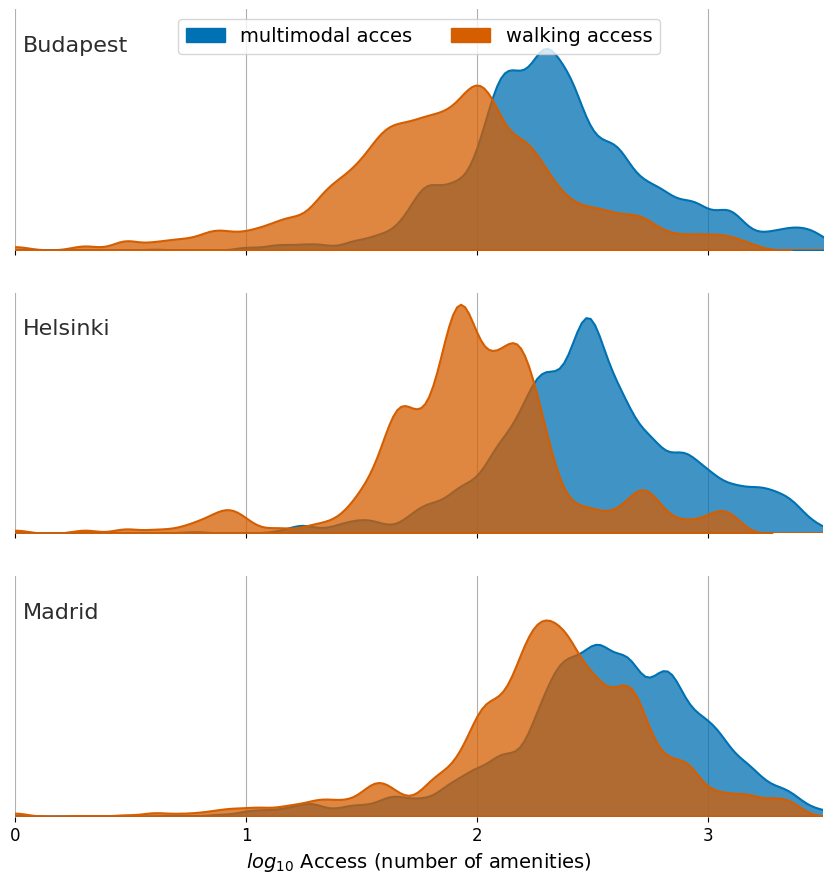

In [155]:
g = sns.FacetGrid(to_plot, row="city", hue="type", aspect=3, height=3, xlim=[0,3.5], palette=["#0071b2", "#d55e00"], legend_out=True)

# Draw the densities in a few steps
g.map(sns.kdeplot, "access_all_log",
      bw_adjust=.5, clip_on=True,
      fill=True, alpha=0.75, linewidth=1.5, legend=True,)
# g.map(sns.kdeplot, "access_all_log", clip_on=True, color="w", lw=2, bw_adjust=.5)
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=True)


for city, ax in g.axes_dict.items():
    ax.text(0.01, 0.85, city, color="#2d2d2d", fontdict=dict(size=16),
            ha="left", va="center", transform=ax.transAxes)
    ax.set_facecolor("none")

elements = [
    Patch(color="#0071b2", label="multimodal acces"),
    Patch(color="#d55e00", label="walking access")
]
g.axes_dict["Budapest"].legend(handles=elements, ncols=2, loc="upper center", fontsize=14)

# Set the subplots to overlap
# g.figure.subplots_adjust(hspace=-.25)
# Remove axes details that don't play well with overlap
g.set_titles("")
g.set(yticks=[], ylabel="")
g.set_xlabels("$log_{10}$ Access (number of amenities)", fontsize=14)
g.despine(bottom=True, left=True)
g.set(xticks=range(0, 4))
g.set_xticklabels(range(0, 4), fontsize=12)
for ax in g.axes.flatten():
    ax.set_axisbelow(True)
    ax.grid()  

for i in ["png", "svg", "pdf"]:
    g.savefig(f"../output/figures/access_distribution_by_city.{i}")

In [ ]:

bud["distance_betweenness_bin"] = pd.qcut(np.log10(bud["distance_betweenness"]).tolist(), 2, labels=["1", "2"])

In [22]:
to_plot2 = pd.DataFrame()
for x, city in zip([bud, hel, mad], ["Budapest", "Helsinki", "Madrid"]):
    x["distance_betweenness_bin"] = pd.qcut(np.log10(x["distance_betweenness"]).tolist(), 2, labels=["1", "2"])
    temp = x[["stop_id", "distance_betweenness_bin", "ellipticity"]].copy()
    temp["city"] = city
    to_plot2 = pd.concat([to_plot2, temp])

In [24]:
to_plot2

,stop_id,distance_betweenness_bin,ellipticity,city
0,007877,1,0.8734,Budapest
1,007879,2,0.4497,Budapest
2,007881,1,0.6902,Budapest
3,007883,1,0.5772,Budapest
4,007884,1,0.4033,Budapest
...,...,...,...,...
2052,17643,2,0.8385,Madrid
2053,17688,2,0.5311,Madrid
2054,18927,2,0.8544,Madrid
2055,18928,2,0.7243,Madrid


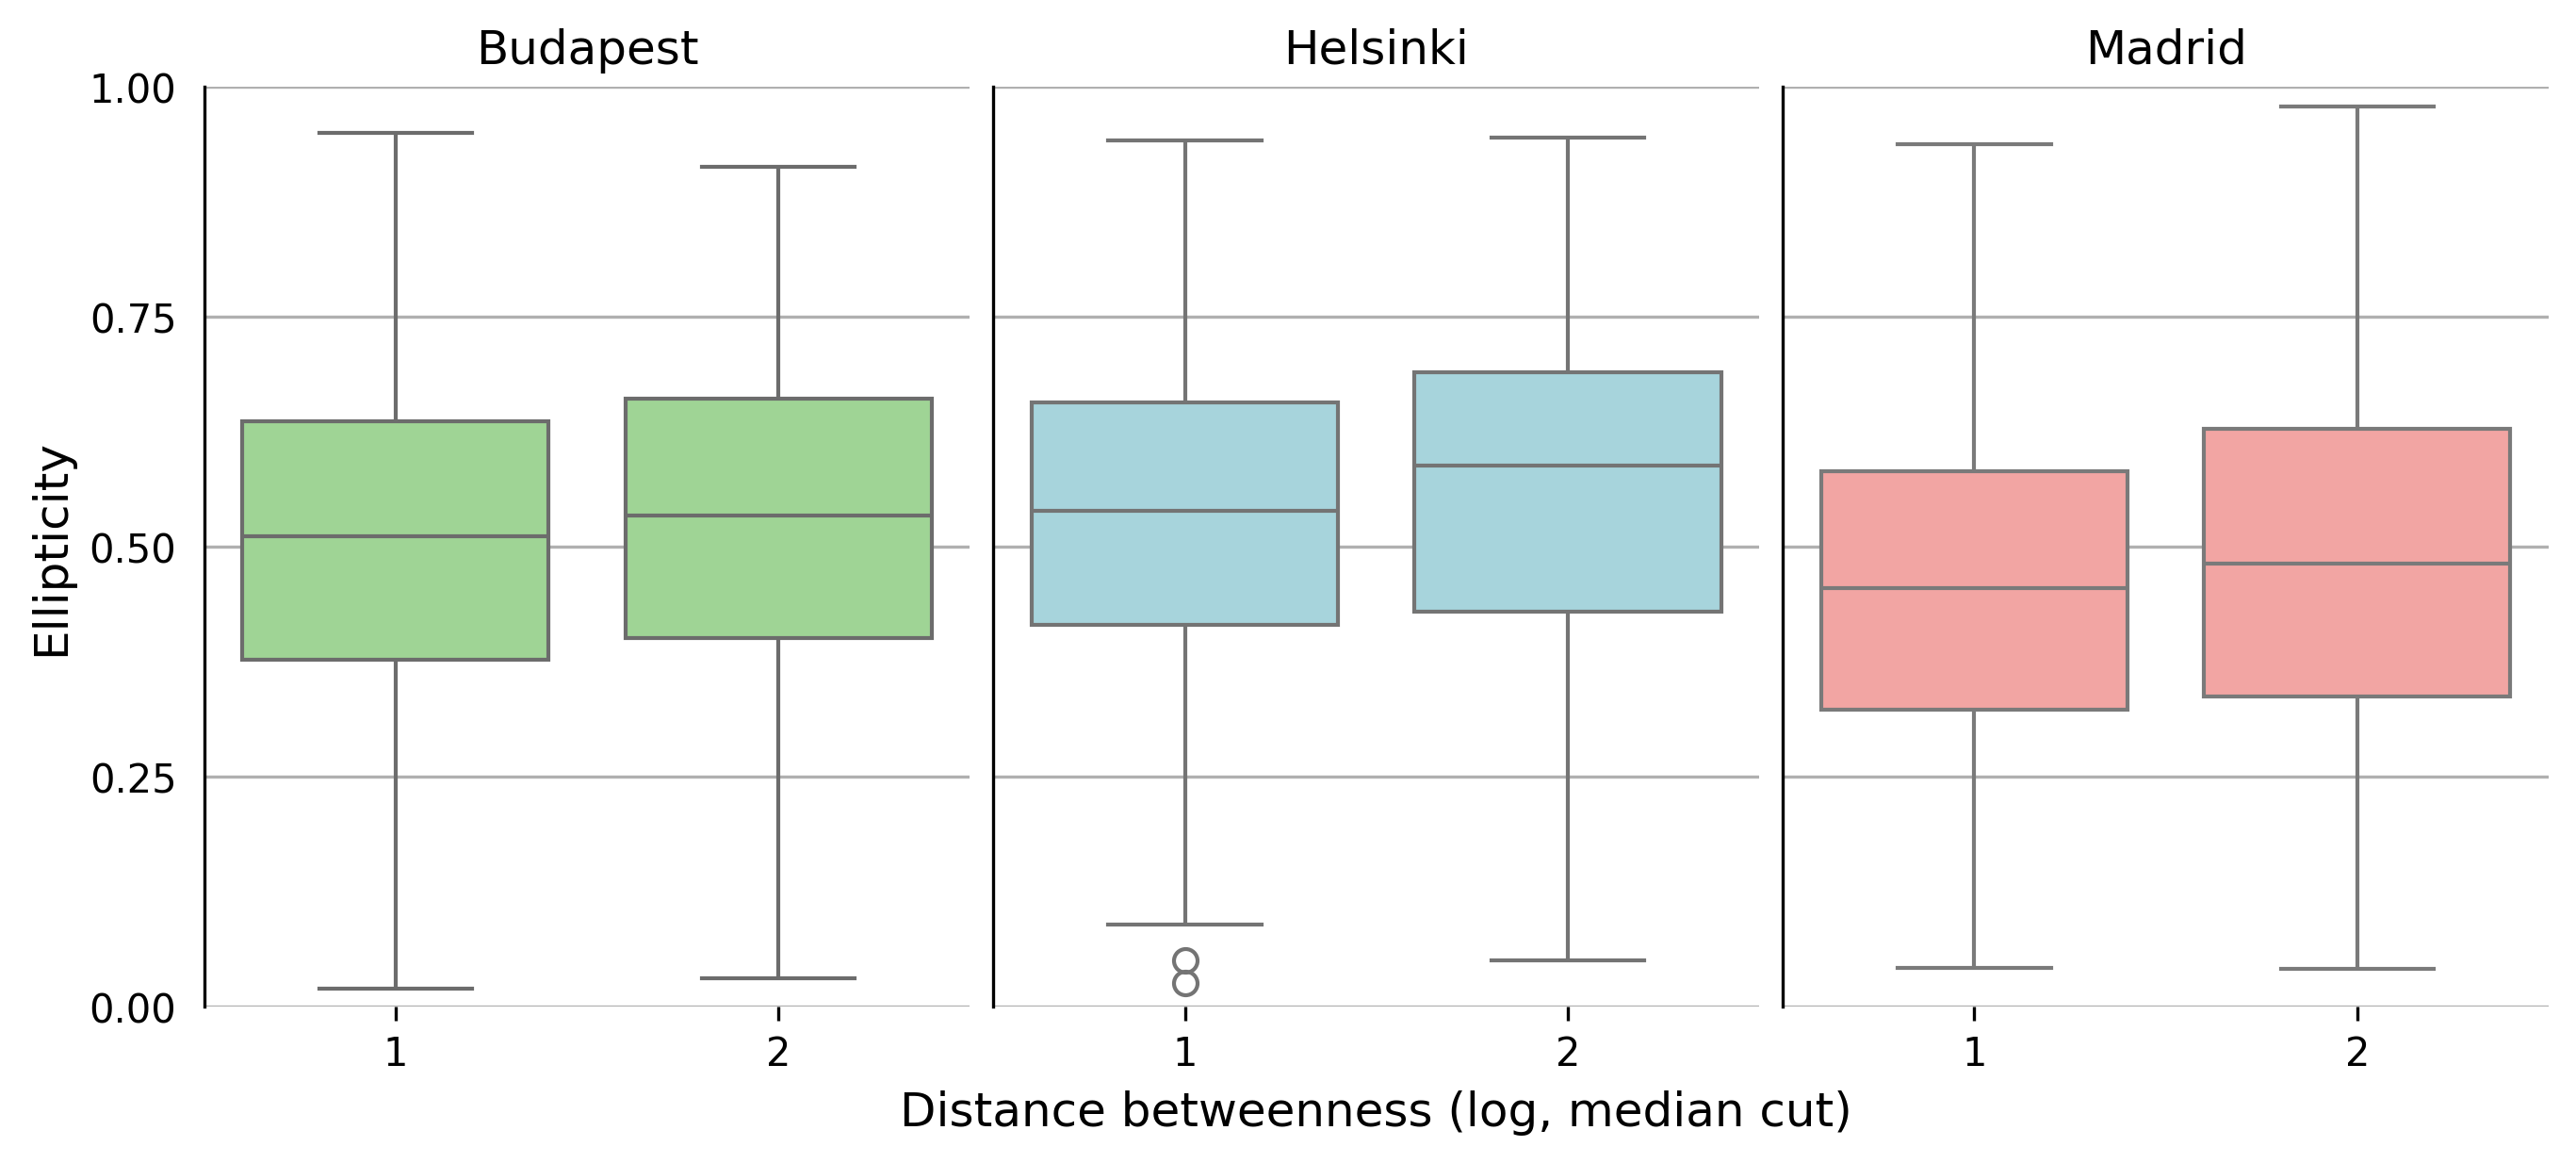

In [77]:
colors = ["#cc79a7", "#56b4e9", "#009e73"]
colors = ["#98df8a", "#9edae5", "#ff9896"]
fig, axs = plt.subplots(ncols=3, layout="constrained", figsize=(9, 4), dpi=300, sharey=True)
for d, a, c, t in zip([bud, hel, mad], axs, colors, ["Budapest", "Helsinki", "Madrid"]):
    sns.boxplot(
        data=d, x="distance_betweenness_bin", y="ellipticity",
        ax=a,
        color=c,
    )
    a.set_ylim([0, 1])
    a.set_yticks(np.arange(0, 1.2, 0.25))
    a.set_xlabel("")
    a.set_ylabel("Ellipticity", fontsize=12)
    a.set_title(t)
    a.set_axisbelow(True)
    a.grid(axis="y")  
    a.tick_params(axis='y', which='both', bottom=False, top=False, left=False, right=False)
_ = axs[1].set_xlabel("Distance betweenness (log, median cut)", fontsize=12)

sns.despine(fig, axs[2], top=True, right=True, left=False, bottom=True)
for i in ["png", "svg", "pdf"]:
    fig.savefig(f"../output/figures/ellipticity_by_distance_betweenness.{i}", metadata=config["metadata"][i])

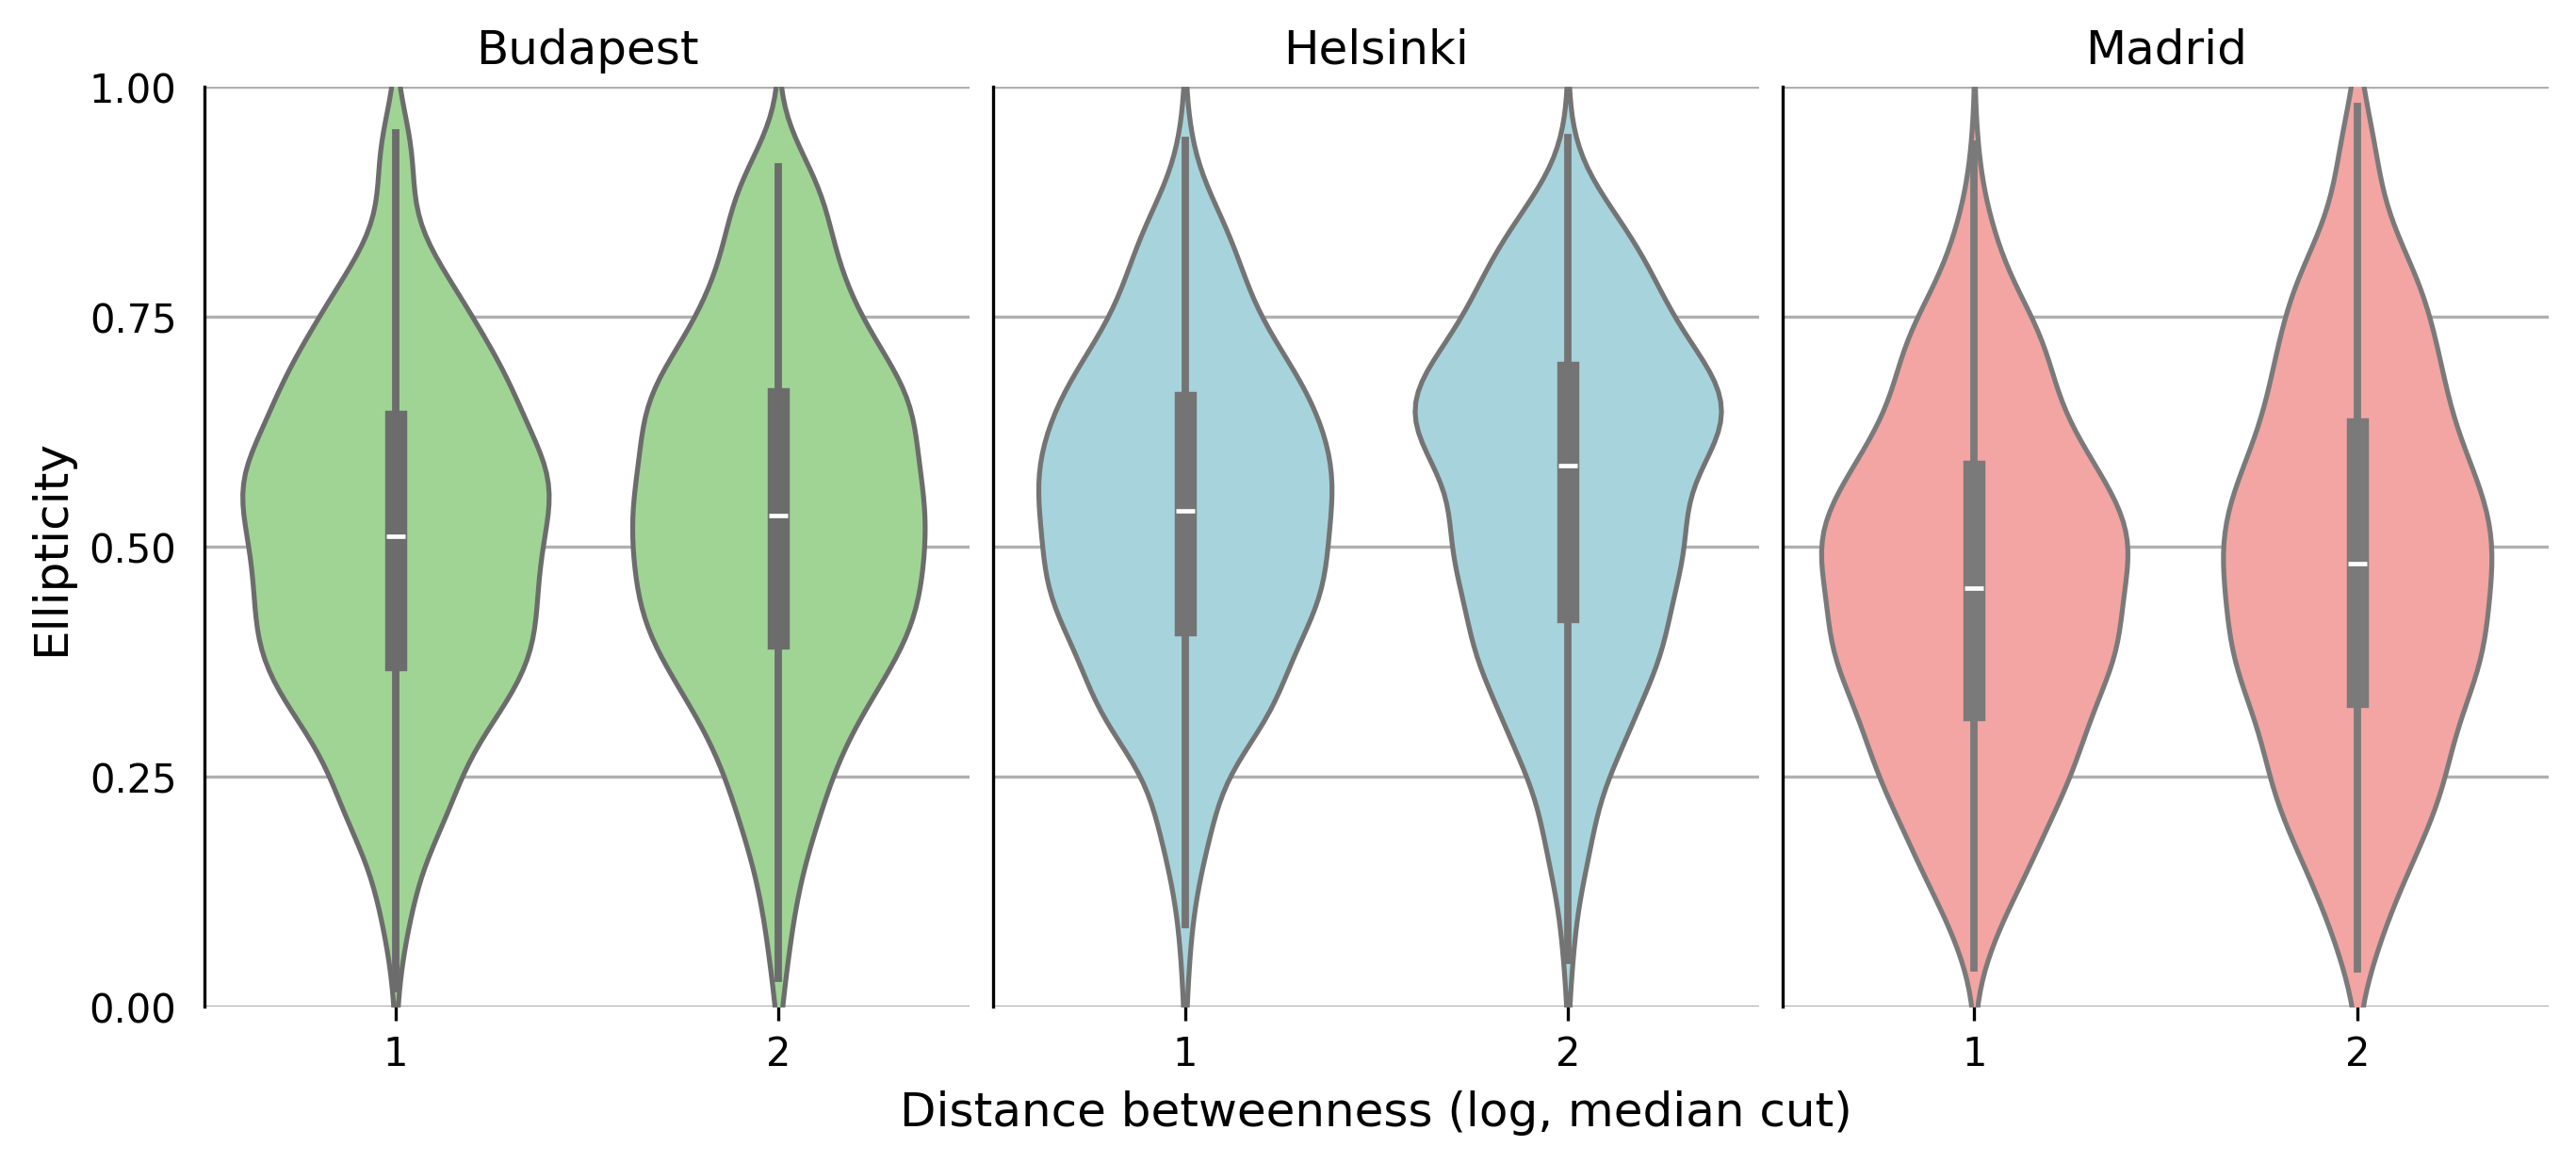

In [78]:
colors = ["#98df8a", "#9edae5", "#ff9896"]
fig, axs = plt.subplots(ncols=3, layout="constrained", figsize=(9, 4), dpi=300, sharey=True)
for d, a, c, t in zip([bud, hel, mad], axs, colors, ["Budapest", "Helsinki", "Madrid"]):
    sns.violinplot(
        data=d, x="distance_betweenness_bin", y="ellipticity",
        ax=a,
        color=c,
    )
    a.set_ylim([0, 1])
    a.set_yticks(np.arange(0, 1.2, 0.25))
    a.set_xlabel("")
    a.set_ylabel("Ellipticity", fontsize=12)
    a.set_title(t)
    a.set_axisbelow(True)
    a.grid(axis="y")  
    a.tick_params(axis='y', which='both', bottom=False, top=False, left=False, right=False)
_ = axs[1].set_xlabel("Distance betweenness (log, median cut)", fontsize=12)

sns.despine(fig, axs[2], top=True, right=True, left=False, bottom=True)
for i in ["png", "svg", "pdf"]:
    fig.savefig(f"../output/figures/ellipticity_by_distance_betweenness_violin.{i}", metadata=config["metadata"][i])